# Dice Roll Simulation — Central Limit Theorem

## What This Notebook Is About

This notebook uses a simple, familiar experiment — **rolling dice** — to demonstrate one of the most important results in all of statistics: the **Central Limit Theorem (CLT)**.

---

### The Central Limit Theorem (in plain English)

> **No matter what shape the distribution of a single random variable has, the distribution of the *sum* (or *average*) of many independent copies of it tends toward a bell curve (normal distribution) as the number of observations grows.**

When you roll **1 die**, the result is equally likely to be 1, 2, 3, 4, 5, or 6. That's a **uniform** (flat) distribution — the opposite of a bell curve.

When you roll **4 dice** and add them up, you start to see a hump in the middle — a handful of ways to get a sum of 14 (the midpoint), but only one way to get 4 (all ones) or 24 (all sixes).

When you roll **12 dice**, the sum looks almost perfectly **bell-shaped (normal)**.

---

### Why Does This Matter?

The CLT is the reason why so many statistical methods — t-tests, confidence intervals, regression — work in practice. They all rely on the assumption that averages/sums are approximately normally distributed. The CLT guarantees this is true for large enough samples, regardless of the original distribution.

---

### What You Will Learn

| Concept | Where |
|---|---|
| Simulation with `numpy` | Section 3 |
| Using 2D arrays to roll many dice at once | Section 3 |
| Long vs wide format DataFrames | Section 4 |
| FacetGrid — one plot panel per condition | Section 6 |
| Reading probability mass functions | Section 5 |

---

### Libraries Used
- **`numpy`** — fast random number generation and array maths
- **`pandas`** — organise results into a table (DataFrame)
- **`seaborn`** — statistical visualisations
- **`matplotlib`** — the underlying plotting engine

*No prior programming experience required — every line of code is explained.*

## 1. Import Libraries

In [1]:

# Before using any external tool, we must "import" it.
# Think of imports like loading apps — you install them once (pip install ...)
# and import them each time you start a new script or notebook.

import numpy as np
# numpy (alias: np) is the foundation of scientific Python.
# It provides fast arrays and mathematical functions.
# We'll use it for: random number generation (np.random), array operations,
# and maths functions (np.arange, np.sqrt, etc.)

import pandas as pd
# pandas (alias: pd) is the Python equivalent of Excel or R's data.frame.
# The key data structure is a DataFrame: a table with labelled rows and columns.
# We'll use it to organise our simulation results.

import seaborn as sns
# seaborn (alias: sns) is a high-level visualisation library.
# It builds on matplotlib and is designed for statistical charts.
# We'll use: histplot, FacetGrid (for small multiples)

import matplotlib.pyplot as plt
# matplotlib (alias: plt) is the core plotting engine Python.
# seaborn is built on top of it. We use plt directly for: subplots,
# figure sizing, titles, and plt.show() to render plots.


## 2. Configuration

**Best practice**: define all adjustable parameters in one place at the top.
This makes it easy to re-run the analysis with different settings — just change these values instead of hunting through the code.

Try changing `num_simulations` to 100 vs 100,000 and see how the distribution smoothness changes. Try adding more values to `dice_to_roll`.

In [2]:
# Number of simulations — higher = smoother distribution but slower to run.
# 10,000 is a good balance: fast enough to run instantly, smooth enough to be clear.
# (The underscore in 10_000 is just Python's visual thousand-separator — it equals 10000)
num_simulations = 10_000

# A LIST of how many dice to roll in each experiment.
# We'll loop over this list and run a separate simulation for each value.
# [1, 4, 12] → one die, four dice, twelve dice
dice_to_roll = [1, 4, 12]


## 3. Run Simulations

In [3]:
# A DICTIONARY to store results.
# Keys = labels like "1 Die", "4 Dice"; Values = arrays of sums.
# Think of it like a named filing cabinet: results["4 Dice"] retrieves all
# the sum-of-4-dice results.
simulation_results = {}

print("Running simulations...")

# LOOP: iterate over each experiment (1 die, 4 dice, 12 dice)
# Python's `for` loop assigns each item in the list to the variable `num_dice`
# one at a time, executing the indented block for each value.
for num_dice in dice_to_roll:
    # Build a human-readable label.
    # The ternary expression 'Die' if num_dice == 1 else 'Dice' is a compact
    # if/else: returns 'Die' when num_dice is 1, 'Dice' otherwise.
    label = f"{num_dice} {'Die' if num_dice == 1 else 'Dice'}"
    print(f"  Simulating {label}...")

    # ── THE KEY STEP: generate all rolls at once using a 2D array ──
    #
    # np.random.randint(low, high, size=(rows, cols))
    #   low  = 1   → minimum die face (inclusive)
    #   high = 7   → maximum die face (exclusive — so actual max = 6)
    #   size = (num_simulations, num_dice)
    #        → rows = one row per simulation (10,000 rows)
    #        → cols = one column per die (e.g. 4 columns for 4 dice)
    #
    # Visualise the resulting 2D array for 4 dice, 5 simulations:
    #   [[3, 1, 6, 4],    ← simulation 1: rolled 3, 1, 6, 4
    #    [2, 5, 5, 1],    ← simulation 2: rolled 2, 5, 5, 1
    #    [6, 6, 1, 2],    ← simulation 3: ...
    #    [1, 3, 4, 4],
    #    [5, 2, 3, 6]]
    rolls = np.random.randint(1, 7, size=(num_simulations, num_dice))

    # Sum ACROSS COLUMNS for each row (axis=1 means "collapse columns into one number")
    # .sum(axis=0) would sum down rows (totals per die) — NOT what we want
    # .sum(axis=1) sums across columns (total per simulation) — what we want
    # Result: a 1D array of length num_simulations, each value = sum of that roll
    simulation_results[label] = rolls.sum(axis=1)

print("Done!")


Running simulations...
  Simulating 1 Die...
  Simulating 4 Dice...
  Simulating 12 Dice...
Done!


## 4. Organise Results into a DataFrame

A **DataFrame** is Python's equivalent of a spreadsheet table. Each column holds data for one experiment (1 Die, 4 Dice, 12 Dice), and each row is one simulation.

We convert our dictionary of results directly into a DataFrame — pandas handles the rest automatically.

```
         1 Die  4 Dice  12 Dice
row 0        2      14       36     ← simulation 1
row 1        3      18       28     ← simulation 2
...
row 9999     4      15       41     ← simulation 10,000
```

The `.describe()` method gives a quick statistical summary: mean, standard deviation, min, max, and quartiles. Notice how the standard deviation grows with the number of dice (wider distribution = more spread).

In [4]:
# pd.DataFrame(dictionary) converts a dictionary to a DataFrame.
# Dictionary keys → column names; dictionary values → column data.
# pandas aligns the arrays by index (row number) automatically.
df_sums = pd.DataFrame(simulation_results)

# display() is a Jupyter-specific function that renders the DataFrame
# as a nicely formatted HTML table (nicer than plain print()).
print("First 5 rows (each row = one simulation, each column = one experiment):")
display(df_sums.head())      # .head() returns the first 5 rows by default

# .describe() computes summary statistics for every numeric column:
#   count = number of rows, mean = average, std = standard deviation,
#   min/max = extremes, 25%/50%/75% = quartiles (Q1, median, Q3)
# .T transposes: swaps rows and columns (so experiments are rows, not columns)
# .round(3) rounds all numbers to 3 decimal places for readability
print("\nSummary statistics (note how std increases with more dice):")
display(df_sums.describe().T.round(3))


First 5 rows (each row = one simulation, each column = one experiment):


,1 Die,4 Dice,12 Dice
0,2,7,45
1,6,20,53
2,6,12,35
3,3,21,40
4,3,10,52



Summary statistics (note how std increases with more dice):


,count,mean,std,min,25%,50%,75%,max
1 Die,10000.0,3.502,1.705,1.0,2.0,3.0,5.0,6.0
4 Dice,10000.0,14.019,3.423,4.0,12.0,14.0,16.0,24.0
12 Dice,10000.0,42.050,5.903,20.0,38.0,42.0,46.0,66.0


## 5. Visualise — Probability Mass Function

A **Probability Mass Function (PMF)** shows the probability of each possible outcome.

- With **1 die**: each face (1–6) has probability 1/6 ≈ 16.7% → flat/uniform distribution
- With **4 dice**: the sum ranges from 4 to 24. Sums near 14 (the middle) have many ways to occur → mound shape
- With **12 dice**: the sum ranges from 12 to 72. The Central Limit Theorem kicks in → near-perfect bell curve

**Reading the chart**: Each bar's height = the probability of that exact sum. The x-axis shifts right and the distribution widens as we add more dice (because the possible range of sums grows).

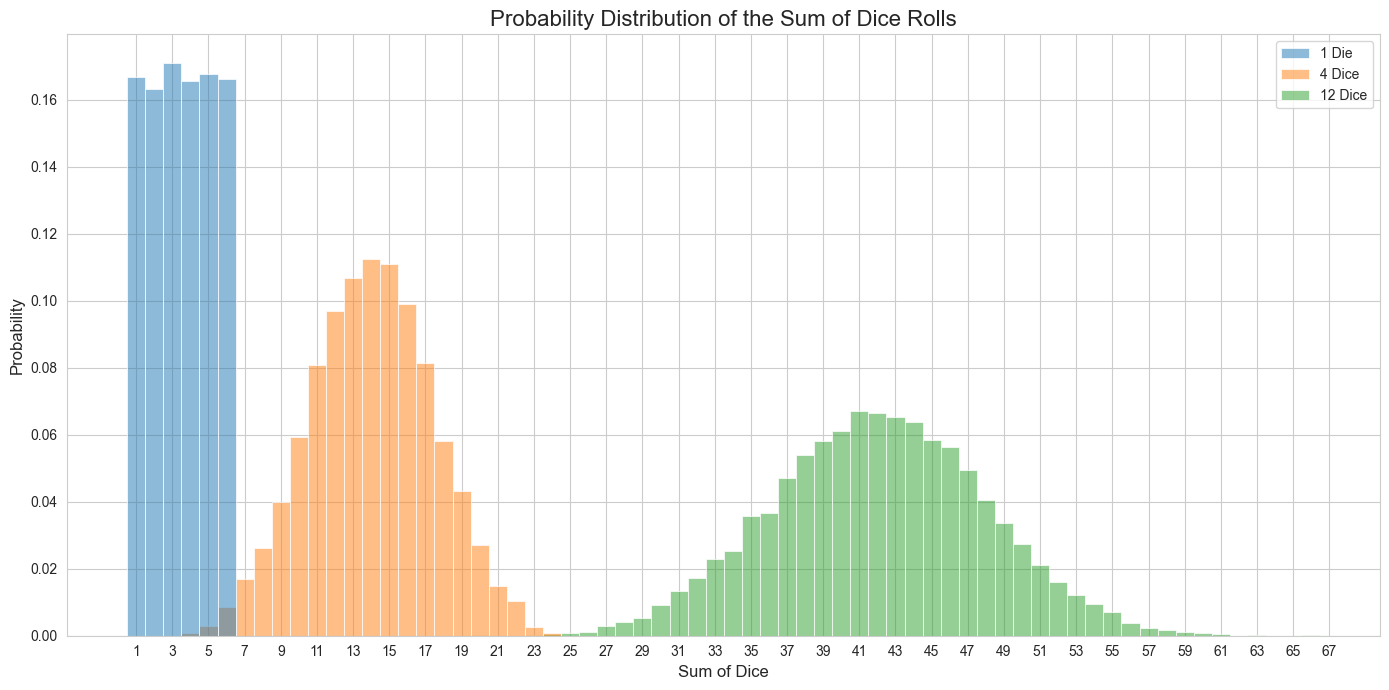

In [5]:
sns.set_style("whitegrid")     # Clean plot style: white background with grid lines

# plt.subplots() creates a Figure (the overall canvas) and Axes (the plot area).
# figsize=(14, 7) sets the size in inches (width × height).
fig, ax = plt.subplots(figsize=(14, 7))

# sns.histplot plots all THREE columns of df_sums in a single call.
# When you pass a wide DataFrame, seaborn automatically creates one
# histogram per column, using different colours.
#
# stat="probability" → y-axis shows P(X = x), not raw counts.
#   This way bars for all three experiments can be compared even though
#   their ranges are different.
# common_norm=False → each experiment's bars sum to 1 independently.
#   (If True, all bars combined would sum to 1 — not what we want here.)
# discrete=True → treat each integer value as its own bar with no gaps.
#   Appropriate since dice sums are whole numbers.
# linewidth=0.5 → thin border around each bar for visual separation.
sns.histplot(
    data=df_sums,
    stat="probability",
    common_norm=False,
    discrete=True,
    linewidth=0.5,
    ax=ax
)

# Always label your plots. ax.set_title(), .set_xlabel(), .set_ylabel() are
# the standard matplotlib functions for adding text labels.
ax.set_title('Probability Distribution of the Sum of Dice Rolls', fontsize=16)
ax.set_xlabel('Sum of Dice', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)

# np.arange(start, stop, step) creates evenly spaced values.
# We want x-tick labels at 1, 3, 5, ... up to the maximum possible sum.
# max().max() → first .max() finds the max of each column, second .max() finds
# the overall maximum across all columns.
max_sum = df_sums.max().max()
ax.set_xticks(np.arange(1, max_sum + 2, 2))    # tick every 2 units to avoid crowding

plt.tight_layout()    # automatically adjust spacing to prevent labels from clipping
plt.show()            # render and display the plot


## 6. Faceted View — One Panel per Experiment

A **FacetGrid** (also called "small multiples") creates one separate plot panel for each value of a categorical variable. This is much easier to read than overlapping all three distributions on one chart.

### Wide vs Long Data Format

The previous plot used **wide** format: one column per experiment.
FacetGrid requires **long** (tidy) format: one row per observation.

**Wide** (what we have):
```
1 Die  4 Dice  12 Dice
    2      14       36
    3      18       28
```

**Long** (what FacetGrid needs):
```
Experiment   Sum
1 Die          2
1 Die          3
4 Dice        14
4 Dice        18
12 Dice       36
```

We use `.melt()` to reshape from wide → long. The `var_name` becomes a new column identifying which experiment each row came from, and `value_name` holds the actual sum value.

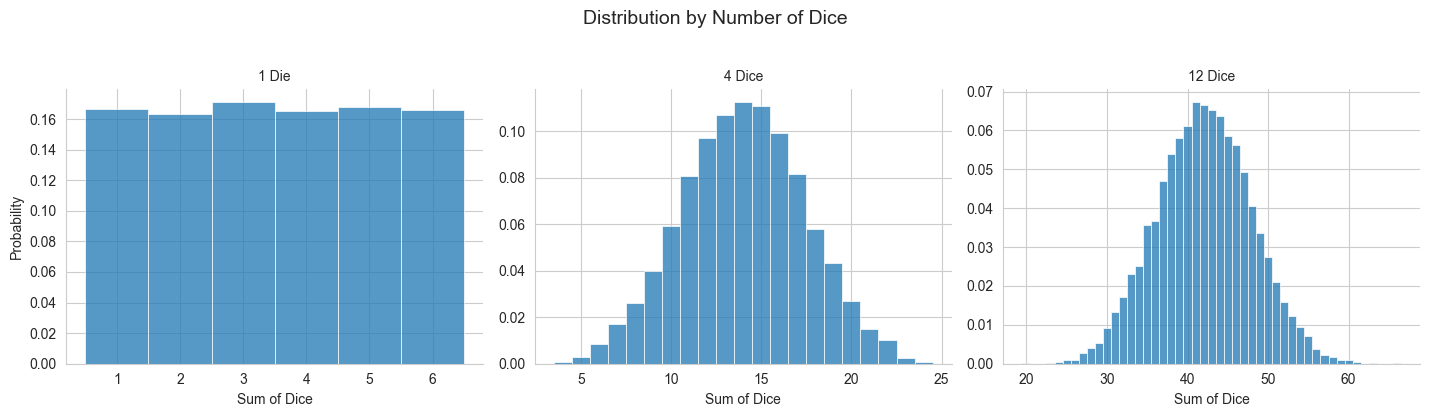

In [7]:
# .melt() reshapes from WIDE format to LONG (tidy) format.
# var_name='Experiment'  → the new column that holds the original column names
#                          (will contain "1 Die", "4 Dice", "12 Dice")
# value_name='Sum'       → the new column that holds the actual values
# After melt, df_long has 30,000 rows: 10,000 for each of the 3 experiments
df_long = df_sums.melt(var_name='Experiment', value_name='Sum')

# sns.FacetGrid: creates a grid of axes, one per category.
# col='Experiment'  → one column (panel) per unique value of 'Experiment'
# sharey=False      → each panel can have its own y-axis scale (good when
#                     probabilities differ across experiments)
# height=4          → each panel is 4 inches tall
# aspect=1.2        → each panel is 1.2× as wide as it is tall
g = sns.FacetGrid(df_long, col='Experiment', sharex=False, sharey=False, height=4, aspect=1.2)

# .map() applies the same plotting function to each panel.
# The first argument is the function (sns.histplot).
# Subsequent arguments are the column(s) to plot and any extra options.
# 'Sum' is the x-axis variable; the remaining keyword args are passed to histplot.
g.map(sns.histplot, 'Sum', stat='probability', discrete=True, linewidth=0.5)

# Axis labels and overall title
g.set_axis_labels('Sum of Dice', 'Probability')
g.set_titles('{col_name}')         # {col_name} is replaced by "1 Die", "4 Dice", etc.
g.figure.suptitle('Distribution by Number of Dice', y=1.03, fontsize=14)
# y=1.03 places the super-title slightly above the panels to avoid overlap

plt.tight_layout()
plt.show()
